In [158]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [159]:
df = pd.read_csv('./test_data.csv')

In [160]:
df.tail()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
72,LP001877,Male,Yes,2,Graduate,No,4708,1387.0,150.0,360.0,1.0,Semiurban,Y
73,LP001319,Male,Yes,2,Not Graduate,No,3273,1820.0,81.0,360.0,1.0,Urban,Y
74,LP002272,Male,Yes,2,Graduate,No,3276,484.0,135.0,360.0,NaN,Semiurban,Y
75,LP002407,Female,Yes,0,Not Graduate,Yes,7142,0.0,138.0,360.0,1.0,Rural,Y
76,LP002840,Female,No,0,Graduate,No,2378,0.0,9.0,360.0,1.0,Urban,N


In [161]:
print(df['Loan_Status'].value_counts(normalize = 'true'))

Loan_Status
Y    0.727273
N    0.272727
Name: proportion, dtype: float64


In [162]:
print(df.duplicated().sum())

0


In [163]:
print(df.dtypes)

Loan_ID                  str
Gender                   str
Married                  str
Dependents               str
Education                str
Self_Employed            str
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area            str
Loan_Status              str
dtype: object


In [164]:
le = LabelEncoder()
categ_cols = [ 'Gender','Loan_ID','Married','Dependents','Education', 'Self_Employed', 'Property_Area', 'Loan_Status']

for col in categ_cols:
  df[col] = le.fit_transform(df[col])

print(df.dtypes)

Loan_ID                int64
Gender                 int64
Married                int64
Dependents             int64
Education              int64
Self_Employed          int64
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area          int64
Loan_Status            int64
dtype: object


In [165]:
#null values percentage
df.isna().sum()/len(df)*100

Loan_ID              0.000000
Gender               0.000000
Married              0.000000
Dependents           0.000000
Education            0.000000
Self_Employed        0.000000
ApplicantIncome      0.000000
CoapplicantIncome    0.000000
LoanAmount           0.000000
Loan_Amount_Term     2.597403
Credit_History       9.090909
Property_Area        0.000000
Loan_Status          0.000000
dtype: float64

In [166]:
df['Dependents']=df['Dependents'].fillna(df['Dependents'].mode()[0])
df['Gender']=df['Gender'].fillna(df['Gender'].mode()[0])
df['Self_Employed']=df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])
df['Loan_Amount_Term']=df["Loan_Amount_Term"].fillna(df['Loan_Amount_Term'].median())
df['Credit_History']=df["Credit_History"].fillna(df['Credit_History'].median())
df['Credit_History']=df["Credit_History"].fillna(df['Credit_History'].median())
df['Dependents'] = df['Dependents'].astype(str).str.replace('3+', '3').str.replace('nan', '0')
df['Dependents'] = pd.to_numeric(df['Dependents'], errors='coerce').fillna(0).astype(int)

In [167]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            77 non-null     int64  
 1   Gender             77 non-null     int64  
 2   Married            77 non-null     int64  
 3   Dependents         77 non-null     int64  
 4   Education          77 non-null     int64  
 5   Self_Employed      77 non-null     int64  
 6   ApplicantIncome    77 non-null     int64  
 7   CoapplicantIncome  77 non-null     float64
 8   LoanAmount         77 non-null     float64
 9   Loan_Amount_Term   77 non-null     float64
 10  Credit_History     77 non-null     float64
 11  Property_Area      77 non-null     int64  
 12  Loan_Status        77 non-null     int64  
dtypes: float64(4), int64(9)
memory usage: 7.9 KB


In [168]:
df.describe()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
count,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000
mean,38.000000,0.779221,0.571429,0.740260,0.272727,0.233766,3564.116883,1500.854545,103.818182,336.623377,0.909091,1.116883,0.727273
std,22.371857,0.476373,0.498117,1.093071,0.448282,0.535481,1624.392080,3920.776382,27.132583,73.042352,0.289365,0.777547,0.448282
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,150.000000,0.000000,9.000000,36.000000,0.000000,0.000000,0.000000
25%,19.000000,1.000000,0.000000,0.000000,0.000000,0.000000,2378.000000,0.000000,88.000000,360.000000,1.000000,1.000000,0.000000
50%,38.000000,1.000000,1.000000,0.000000,0.000000,0.000000,3200.000000,985.799988,110.000000,360.000000,1.000000,1.000000,1.000000
75%,57.000000,1.000000,1.000000,1.000000,1.000000,0.000000,4384.000000,1820.000000,120.000000,360.000000,1.000000,2.000000,1.000000
max,76.000000,2.000000,1.000000,4.000000,1.000000,2.000000,8624.000000,33837.000000,150.000000,480.000000,1.000000,2.000000,1.000000


In [169]:
#null values percentage
df.isna().sum()/len(df)*100

Loan_ID              0.0
Gender               0.0
Married              0.0
Dependents           0.0
Education            0.0
Self_Employed        0.0
ApplicantIncome      0.0
CoapplicantIncome    0.0
LoanAmount           0.0
Loan_Amount_Term     0.0
Credit_History       0.0
Property_Area        0.0
Loan_Status          0.0
dtype: float64

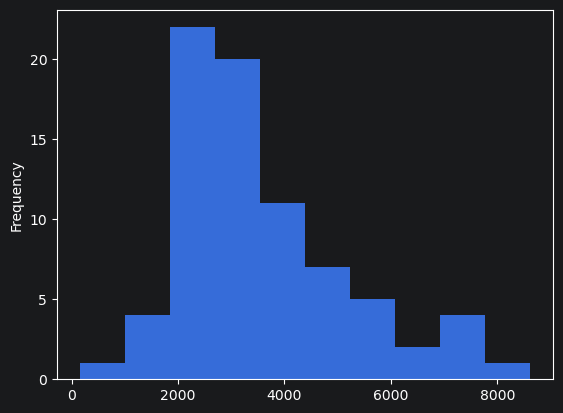

In [170]:
plt.hist(df['ApplicantIncome'])
plt.ylabel("Frequency")
plt.show()

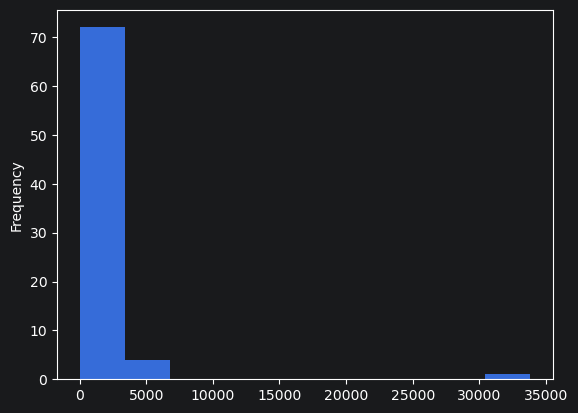

In [171]:
plt.hist(df['CoapplicantIncome'])
plt.ylabel("Frequency")
plt.show()

In [172]:
df['TotalIncome'] = df['ApplicantIncome'] + df['CoapplicantIncome']

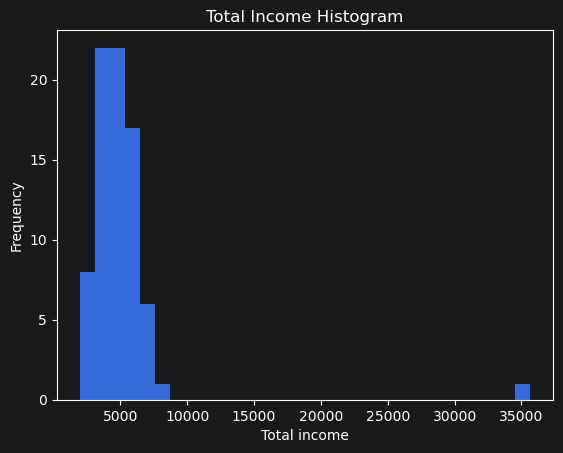

In [173]:
plt.hist(df['TotalIncome'], bins=30)
plt.title("Total Income Histogram")
plt.xlabel("Total income")
plt.ylabel("Frequency")
plt.show()

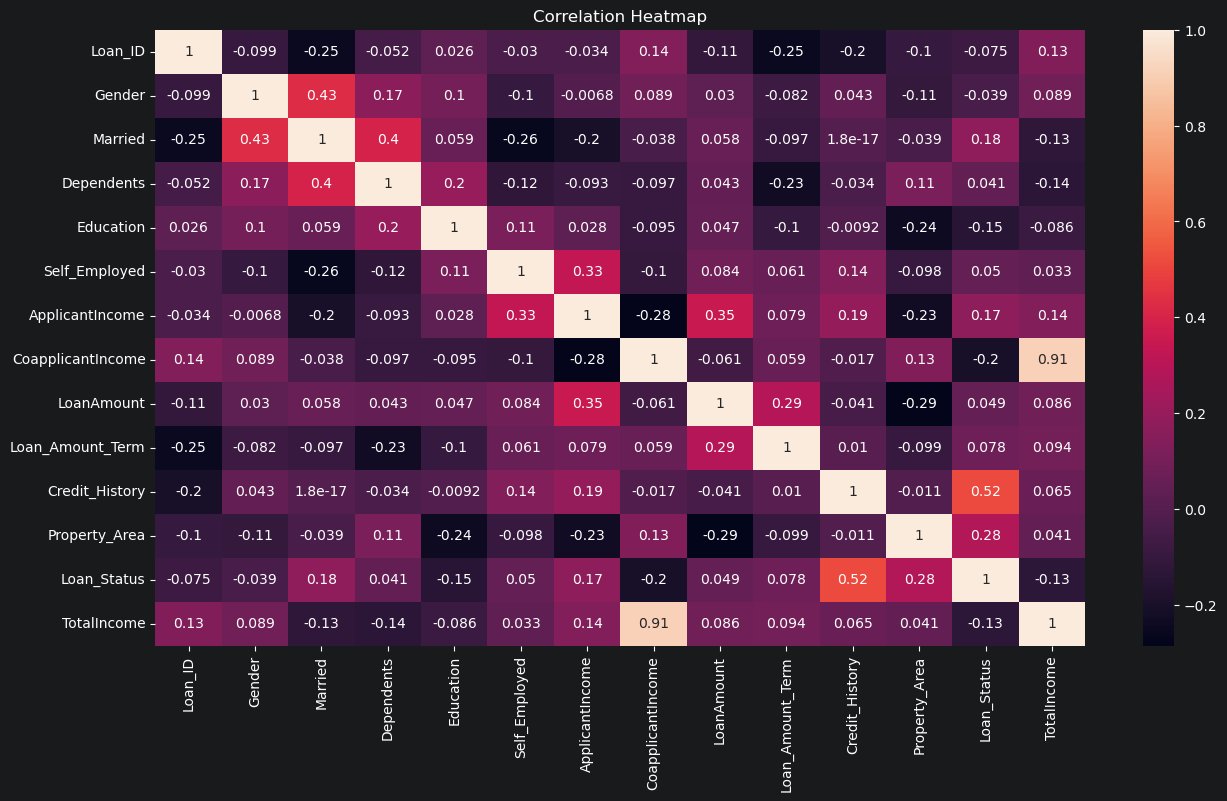

In [174]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.select_dtypes(include=np.number).corr(),annot=True)
plt.title('Correlation Heatmap')
plt.show()

In [175]:
#dropped because the correlation coofecient between it and the loan status is low
#df = df.drop('Gender', axis = 1, errors = 'ignore')

In [176]:
#features will be chosen depending on the corelatino between them and the Loan_Status
features = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
            'Credit_History', 'Property_Area', 'Loan_Amount_Term', 'TotalIncome', 'CoapplicantIncome']
x = df[features]
y = df['Loan_Status']
model = GradientBoostingClassifier(n_estimators=50, learning_rate=0.05, max_depth=1)
model.fit(x, y)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",50
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",1
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [177]:
#------Testing the model
tdf = pd.read_csv("./test_data.csv")
#---Preprocceing Testing data
tdf['TotalIncome'] = tdf['ApplicantIncome'] + tdf['CoapplicantIncome']
categ_cols = [ 'Gender','Loan_ID','Married', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']


tdf['Dependents']=tdf['Dependents'].fillna(tdf['Dependents'].mode()[0])
tdf['Gender']=tdf['Gender'].fillna(tdf['Gender'].mode()[0])
tdf['Self_Employed']=tdf['Self_Employed'].fillna(tdf['Self_Employed'].mode()[0])

tdf['Loan_Amount_Term']=tdf["Loan_Amount_Term"].fillna(tdf['Loan_Amount_Term'].median())
tdf['Credit_History']=tdf["Credit_History"].fillna(tdf['Credit_History'].median())
tdf['Credit_History']=tdf["Credit_History"].fillna(tdf['Credit_History'].median())

for col in categ_cols:
  tdf[col] = le.fit_transform(tdf[col])

tdf['Dependents'] = tdf['Dependents'].astype(str).str.replace('3+', '3').str.replace('nan', '0')
tdf['Dependents'] = pd.to_numeric(tdf['Dependents'], errors='coerce').fillna(0).astype(int)

In [181]:
print(tdf['Loan_Status'].value_counts(normalize = 'true'))

Loan_Status
1    0.727273
0    0.272727
Name: proportion, dtype: float64


In [178]:
# Taking testing varibles
x_test = tdf[features]
y_test = tdf['Loan_Status']

In [196]:
#Evaluating the Model
predictions = model.predict(x)
print(f"Model Accuracy On Its own data  : {accuracy_score(y, predictions)}")
predictions_on_test = model.predict(x_test)
print(f"Model Accuracy On Its test Data : {accuracy_score(y_test, predictions_on_test)}")

Model Accuracy On Its own data  : 0.8311688311688312
Model Accuracy On Its test Data : 0.8311688311688312


In [182]:
#I give up from here you on your own
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model, x, y, cv=5)

print("Scores:", scores)
print("Average Accuracy:", scores.mean())
print("Standard Deviation:", scores.std())

Scores: [0.75       0.9375     0.8        0.8        0.86666667]
Average Accuracy: 0.8308333333333333
Standard Deviation: 0.06495725089968359


In [183]:
from sklearn.metrics import f1_score, roc_auc_score, classification_report
y_pred = model.predict(x_test)
f1 = f1_score(y_test, y_pred)
print(f"F1-Score: {f1:.4f}")

F1-Score: 0.8960


In [184]:
y_probs = model.predict_proba(x_test)[:, 1]
auc = roc_auc_score(y_test, y_probs)
print(f"AUC Score: {auc: .4f}")

AUC Score:  0.9043


In [185]:
rf = RandomForestClassifier(n_estimators=100, max_depth=None, random_state=42)
rf.fit(x, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [186]:
from sklearn.metrics import f1_score, roc_auc_score, classification_report
y_pred = rf.predict(x_test)
f1 = f1_score(y_test, y_pred)
print(f"F1-Score: {f1:.4f}")

F1-Score: 1.0000


In [187]:
predictions = rf.predict(x_test)
print(f"Model Accuracy: {accuracy_score(y_test, predictions)}")

Model Accuracy: 1.0


In [188]:
predictions = rf.predict(x)
print(f"Model Accuracy: {accuracy_score(y, predictions)}")

Model Accuracy: 1.0


In [189]:
from sklearn.metrics import classification_report

# This will show you exactly where the 0.8966 is coming from
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        21
           1       1.00      1.00      1.00        56

    accuracy                           1.00        77
   macro avg       1.00      1.00      1.00        77
weighted avg       1.00      1.00      1.00        77

